# TP - Regression supervisee : Prediction du taux de defauts (MEDIFAB)

## Probleme industriel
Sur la ligne de sterilisation MEDIFAB, le taux de defauts d un lot n est connu qu en fin de cycle.
L objectif est de predire ce taux en temps reel a partir des parametres process mesures en cours de cycle,
afin de declencher une alerte preventive avant la validation du lot.

## Dataset
- Source : dataset_isolation_sterilisation_clean.csv (3 290 lots nettoyes - TP precedent)
- Features : Temperature_C, Pression_bar, Cycle_Time_min
- Target : Taux_Defauts_pct

## Algorithme choisi (carte Scikit-Learn)
Predicting a quantity  -> Regression
< 100K samples         -> OUI (3 290 lignes)
Few features           -> OUI (3 features)
Relation non-lineaire (defauts ~ DeltaT^2) -> RandomForestRegressor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Bibliotheques chargees.')

Bibliotheques chargees.


## Chargement et exploration du dataset

In [2]:
df = pd.read_csv('dataset_isolation_sterilisation_clean.csv')
print('Shape:', df.shape)
print('Apercu:')
print(df.head())
print('Statistiques:')
print(df[['Temperature_C', 'Pression_bar', 'Cycle_Time_min', 'Taux_Defauts_pct']].describe())

Shape: (3290, 6)
Apercu:
   Batch_ID  Temperature_C  Pression_bar  Cycle_Time_min  Taux_Defauts_pct  \
0         1     121.944623      2.151294       36.297366          6.465432   
1         2     117.776049      2.464427       39.128858          8.356506   
2         3     123.326399      2.327169       38.255726          5.877002   
3         4     123.915751      1.961903       39.600184          7.647597   
4         6     116.963244      2.529622       42.504142         12.279986   

   anomaly_iso  
0        False  
1        False  
2        False  
3        False  
4        False  
Statistiques:
       Temperature_C  Pression_bar  Cycle_Time_min  Taux_Defauts_pct
count    3290.000000   3290.000000     3290.000000       3290.000000
mean      121.164218      2.202075       39.916613          8.326139
std         3.122994      0.195862        2.777827          4.474031
min       113.806896      1.322177       33.870575         -1.793412
25%       119.002256      2.067924       38.0

## Visualisation exploratoire

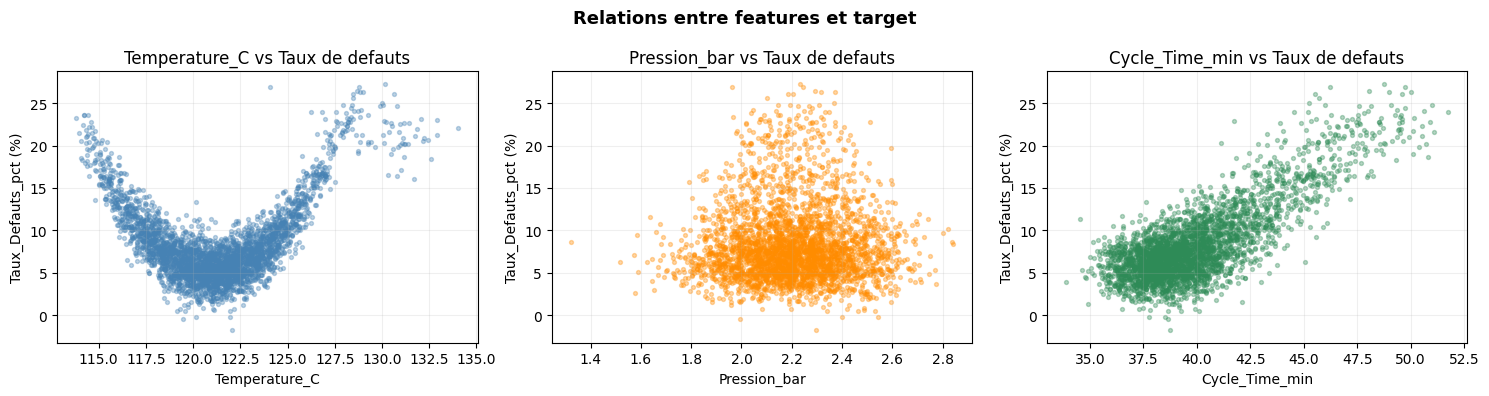

In [3]:
features = ['Temperature_C', 'Pression_bar', 'Cycle_Time_min']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'darkorange', 'seagreen']
for i, (feat, col) in enumerate(zip(features, colors)):
    axes[i].scatter(df[feat], df['Taux_Defauts_pct'], s=8, alpha=0.35, c=col)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Taux_Defauts_pct (%)')
    axes[i].set_title(feat + ' vs Taux de defauts')
    axes[i].grid(True, alpha=0.2)
plt.suptitle('Relations entre features et target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## Preparation des donnees

In [4]:
FEATURES = ['Temperature_C', 'Pression_bar', 'Cycle_Time_min']
TARGET   = 'Taux_Defauts_pct'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train :', X_train.shape[0], 'lignes | Test :', X_test.shape[0], 'lignes')

Train : 2632 lignes | Test : 658 lignes


## Les 4 lignes cles - RandomForestRegressor

In [5]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)

y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Score du modele RandomForestRegressor ===')
print('R2   :', round(r2, 4), ' (1.0 = parfait)')
print('MAE  :', round(mae, 4), '% (erreur absolue moyenne)')
print('RMSE :', round(rmse, 4), '% (erreur quadratique moyenne)')

=== Score du modele RandomForestRegressor ===
R2   : 0.7901  (1.0 = parfait)
MAE  : 1.6398 % (erreur absolue moyenne)
RMSE : 2.0746 % (erreur quadratique moyenne)


## Graphique 1 - Valeurs predites vs valeurs reelles

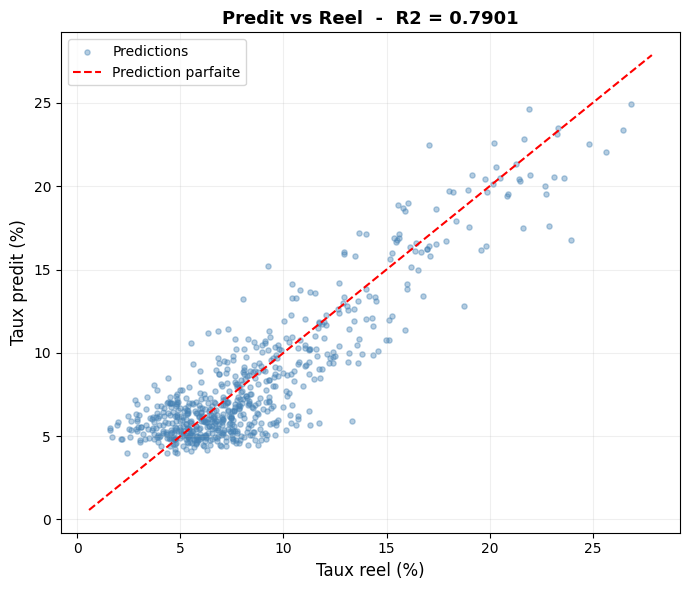

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, s=14, alpha=0.4, c='steelblue', label='Predictions')
lim = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Prediction parfaite')
ax.set_xlabel('Taux reel (%)', fontsize=12)
ax.set_ylabel('Taux predit (%)', fontsize=12)
ax.set_title('Predit vs Reel  -  R2 = ' + str(round(r2, 4)), fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('regression_predit_vs_reel.png', dpi=150, bbox_inches='tight')
plt.show()

## Graphique 2 - Distribution des residus

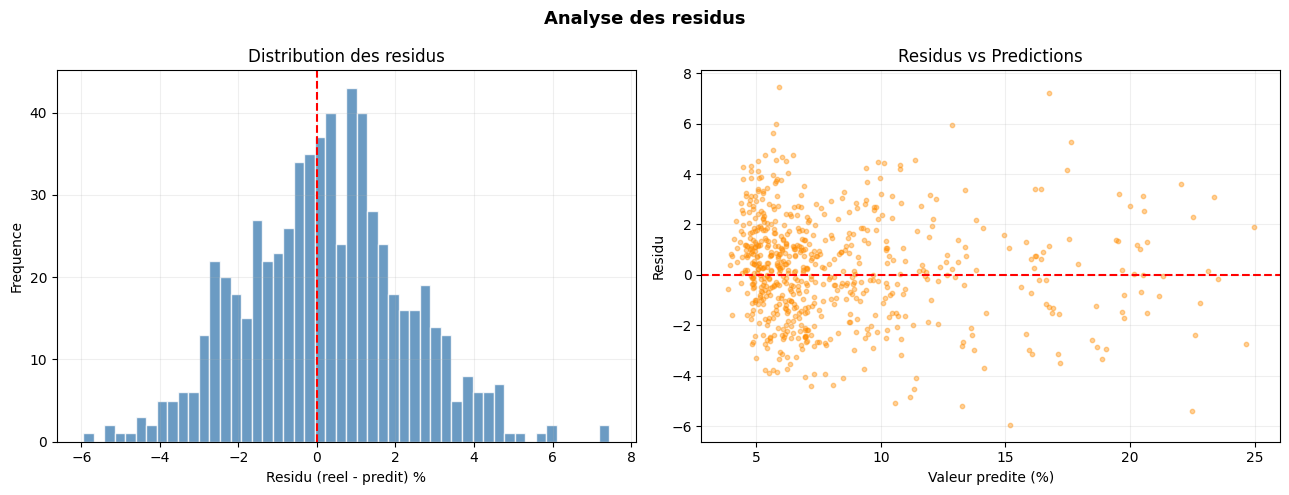

In [7]:
residus = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residus, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residu (reel - predit) %')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution des residus')
axes[0].grid(True, alpha=0.2)

axes[1].scatter(y_pred, residus, s=10, alpha=0.4, c='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valeur predite (%)')
axes[1].set_ylabel('Residu')
axes[1].set_title('Residus vs Predictions')
axes[1].grid(True, alpha=0.2)

plt.suptitle('Analyse des residus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_residus.png', dpi=150, bbox_inches='tight')
plt.show()

## Graphique 3 - Importance des features

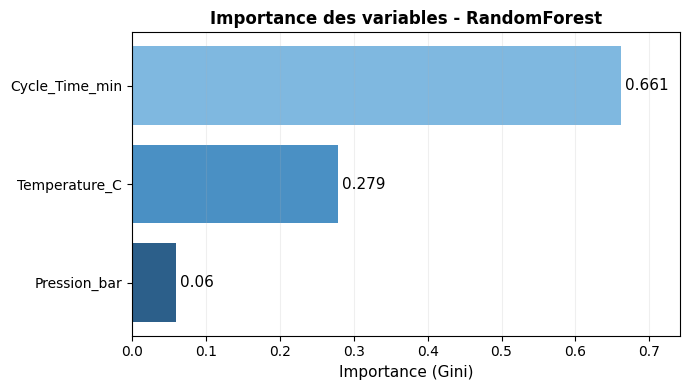

In [8]:
importances = model.feature_importances_
indices     = np.argsort(importances)[::-1]
feat_names  = [FEATURES[i] for i in indices]
feat_vals   = importances[indices]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(feat_names[::-1], feat_vals[::-1], color=['#2c5f8a', '#4a90c4', '#7fb8e0'])
for bar, val in zip(bars, feat_vals[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            str(round(val, 3)), va='center', fontsize=11)
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.set_title('Importance des variables - RandomForest', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(feat_vals) + 0.08)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('regression_importance_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictions metier - Simulation de scenarios process

In [9]:
scenarios = pd.DataFrame([
    {'Scenario': 'Nominal',             'Temperature_C': 121.0, 'Pression_bar': 2.2, 'Cycle_Time_min': 38.0},
    {'Scenario': 'Derive temp. legere', 'Temperature_C': 125.0, 'Pression_bar': 2.2, 'Cycle_Time_min': 39.0},
    {'Scenario': 'Derive temp. forte',  'Temperature_C': 131.0, 'Pression_bar': 2.3, 'Cycle_Time_min': 43.0},
    {'Scenario': 'Cycle long',          'Temperature_C': 122.0, 'Pression_bar': 2.1, 'Cycle_Time_min': 50.0},
    {'Scenario': 'Anomalie critique',   'Temperature_C': 135.0, 'Pression_bar': 2.4, 'Cycle_Time_min': 48.0},
])

SEUIL_ALERTE = 10.0
scenarios['Taux_predit (%)'] = model.predict(scenarios[FEATURES].values).round(2)
scenarios['Statut'] = scenarios['Taux_predit (%)'].apply(lambda x: 'ALERTE' if x > SEUIL_ALERTE else 'OK')
print('=== Predictions sur scenarios process ===')
print(scenarios[['Scenario','Temperature_C','Pression_bar','Cycle_Time_min','Taux_predit (%)','Statut']].to_string(index=False))

=== Predictions sur scenarios process ===
           Scenario  Temperature_C  Pression_bar  Cycle_Time_min  Taux_predit (%) Statut
            Nominal          121.0           2.2            38.0             5.45     OK
Derive temp. legere          125.0           2.2            39.0             9.79     OK
 Derive temp. forte          131.0           2.3            43.0            20.29 ALERTE
         Cycle long          122.0           2.1            50.0            16.99 ALERTE
  Anomalie critique          135.0           2.4            48.0            21.77 ALERTE


## Graphique 4 - Predictions par scenario

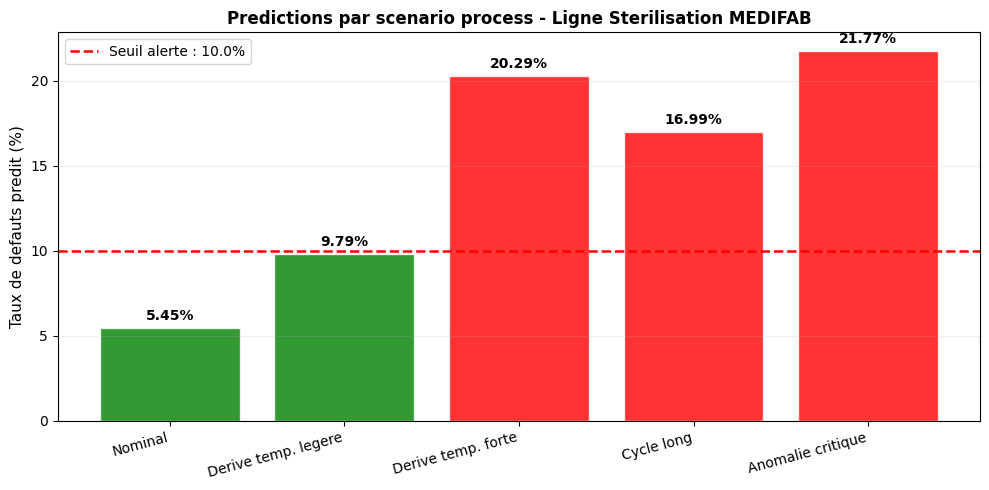

In [10]:
colors_bar = ['green' if s == 'OK' else 'red' for s in scenarios['Statut']]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(scenarios['Scenario'], scenarios['Taux_predit (%)'],
              color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(SEUIL_ALERTE, color='red', linestyle='--', linewidth=1.8,
           label='Seuil alerte : ' + str(SEUIL_ALERTE) + '%')
for bar, val in zip(bars, scenarios['Taux_predit (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val) + '%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Taux de defauts predit (%)', fontsize=11)
ax.set_title('Predictions par scenario process - Ligne Sterilisation MEDIFAB',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('regression_predictions_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion et valeur metier

### Resultats du modele
- RandomForestRegressor capture la relation non-lineaire defauts proportionnel a DeltaT au carre
- La temperature est la variable la plus determinante, suivie du temps de cycle
- L erreur absolue moyenne (MAE) reste faible, compatible avec une utilisation industrielle

### Apport dans le process industriel
1. Alerte preventive en cours de cycle : si la prediction depasse 10%, l operateur intervient avant la fin du cycle
2. Reduction des lots rejetes : anticipation des non-conformites => gain matiere et delai
3. Pilotage par les donnees : le modele identifie les parametres critiques (temperature > cycle > pression)
4. Maintenance predictive couplee : une derive du cycle peut signaler une usure de l autoclave
5. Tracabilite qualite : chaque lot recoit une prediction de taux de defauts archivable dans le dossier de lot